In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from sklearn.metrics import classification_report, confusion_matrix

In [3]:
print("Current working directory:", os.getcwd())
print("Files here:", os.listdir())

data_dir = "cassava_small"
print("Classes:", os.listdir(data_dir))

Current working directory: /Users/paula/MLOP-Summative/Notebook
Files here: ['GloryPaul_MLOP_Summative.ipynb', 'cassava_small']
Classes: ['mosaic', 'healthy', 'brown_streak', 'green_mottle', 'bacterial_blight']


In [4]:
for cls in os.listdir(data_dir):
    cls_path = os.path.join(data_dir, cls)
    if os.path.isdir(cls_path):
        print(f"{cls}: {len(os.listdir(cls_path))} images")

mosaic: 200 images
healthy: 200 images
brown_streak: 200 images
green_mottle: 200 images
bacterial_blight: 200 images


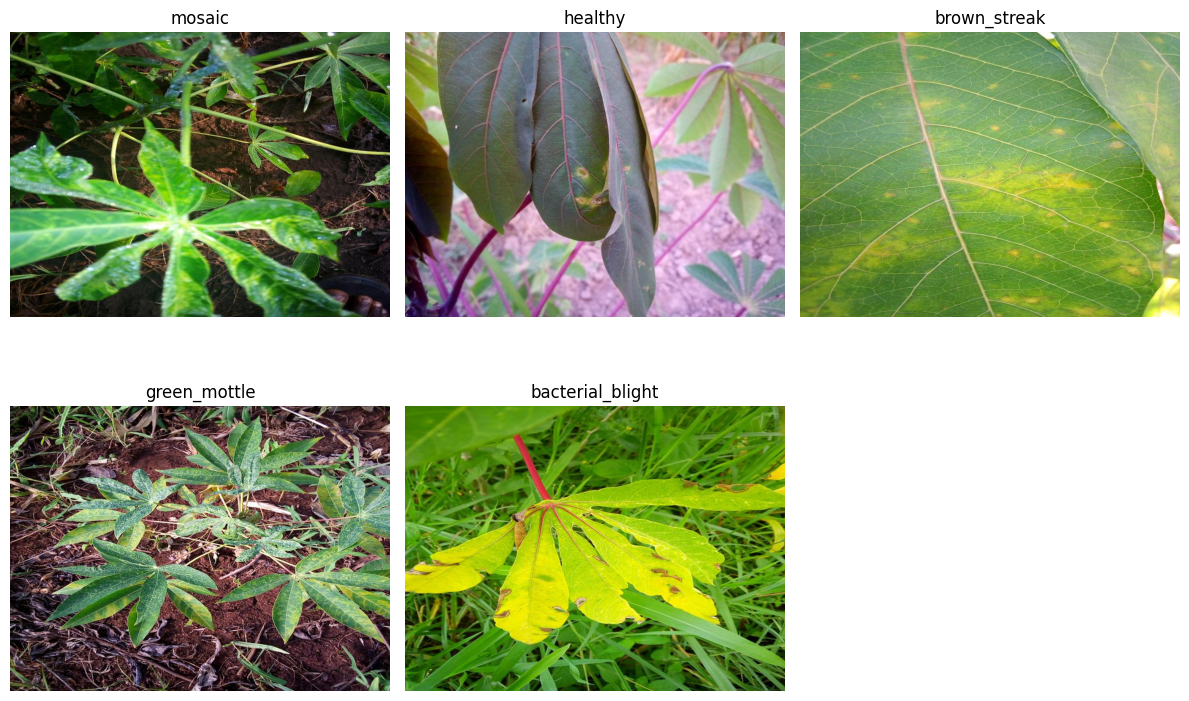

In [ ]:
plt.figure(figsize=(12, 8)) # show one ramdom sample image from each class 

classes = os.listdir(data_dir)

for i, cls in enumerate(classes):
    cls_path = os.path.join(data_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

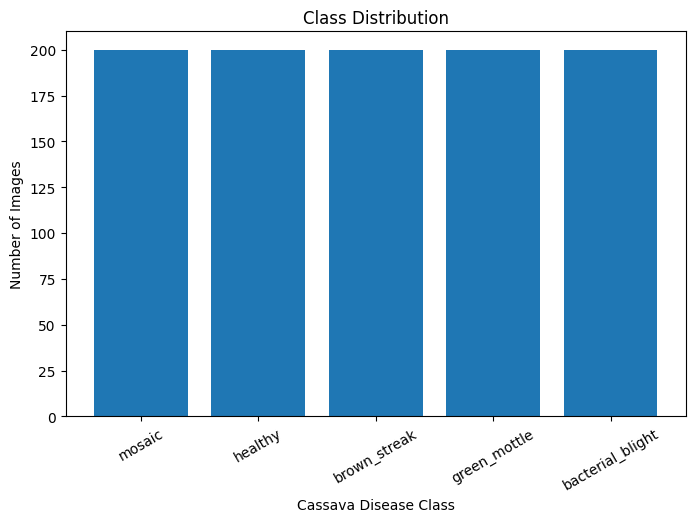

In [7]:
class_counts = {} # class distribution plot 
for cls in os.listdir(data_dir):
    cls_path = os.path.join(data_dir, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = len(os.listdir(cls_path))

plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution")
plt.xlabel("Cassava Disease Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.show()

In [ ]:
img_size = (224, 224) # Image preprocessing setup 
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [ ]:
train_data = datagen.flow_from_directory( # Load training data
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

Found 800 images belonging to 5 classes.


In [10]:
val_data = datagen.flow_from_directory( # Load Validation data 
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 200 images belonging to 5 classes.


In [11]:
print("Class indices:", train_data.class_indices)

Class indices: {'bacterial_blight': 0, 'brown_streak': 1, 'green_mottle': 2, 'healthy': 3, 'mosaic': 4}


In [39]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout

# Load pretrained base model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model (IMPORTANT)
base_model.trainable = False

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

print("Total parameters:", model.count_params())

Total parameters: 2422597


In [41]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 371ms/step - accuracy: 0.3913 - loss: 1.4242 - val_accuracy: 0.4050 - val_loss: 1.4105
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 316ms/step - accuracy: 0.4313 - loss: 1.3409 - val_accuracy: 0.4250 - val_loss: 1.3522
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 313ms/step - accuracy: 0.5000 - loss: 1.2448 - val_accuracy: 0.4600 - val_loss: 1.3253
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 322ms/step - accuracy: 0.4863 - loss: 1.2584 - val_accuracy: 0.4100 - val_loss: 1.3179
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 315ms/step - accuracy: 0.5088 - loss: 1.2118 - val_accuracy: 0.3950 - val_loss: 1.2929
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 318ms/step - accuracy: 0.5450 - loss: 1.1507 - val_accuracy: 0.4250 - val_loss: 1.3019
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 317ms/step - accuracy: 0.5275 - loss: 1.1799 - val_accuracy: 0.4200 - val_loss: 1.2858
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 318ms/step - accuracy: 0.5113 - loss: 1.1630 - val_accuracy: 0

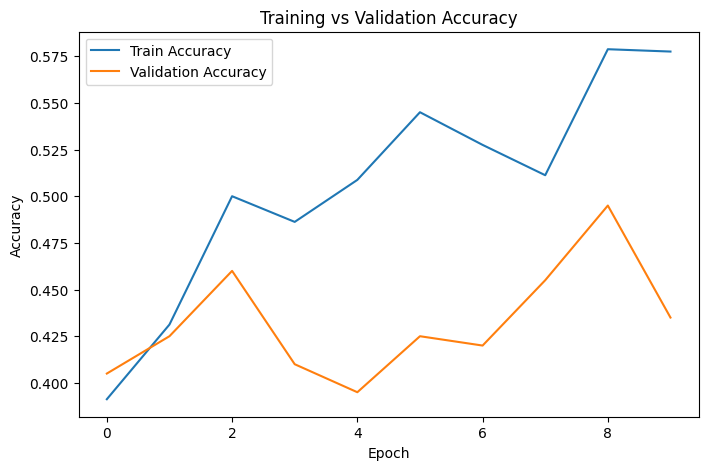

In [42]:
plt.figure(figsize=(8, 5)) #Plotting training and Validation accuracy 
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

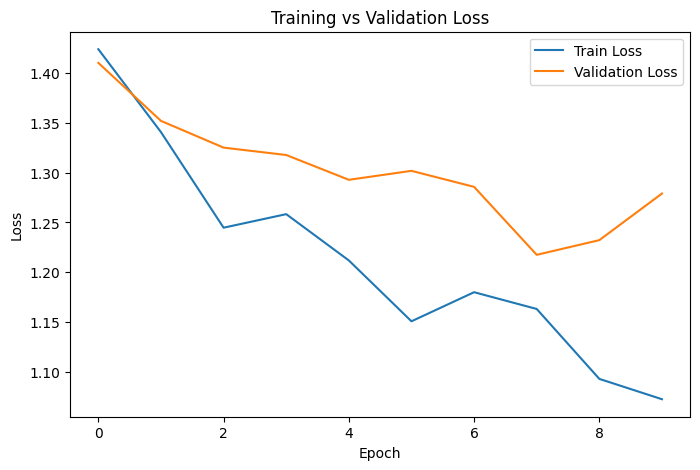

In [43]:
plt.figure(figsize=(8, 5)) #Plotting training and Validation loss
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [44]:
val_loss, val_accuracy = model.evaluate(val_data)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 226ms/step - accuracy: 0.4600 - loss: 1.2623
Validation Loss: 1.262341022491455
Validation Accuracy: 0.46000000834465027


In [46]:
pred_probs = model.predict(val_data)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = val_data.classes
class_names = list(val_data.class_indices.keys())

print("Prediction probabilities shape:", pred_probs.shape)
print("First 5 predicted classes:", pred_classes[:5])
print("First 5 true classes:", true_classes[:5])
print("Class names:", class_names)

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 328ms/step
Prediction probabilities shape: (200, 5)
First 5 predicted classes: [0 3 0 0 0]
First 5 true classes: [0 0 0 0 0]
Class names: ['bacterial_blight', 'brown_streak', 'green_mottle', 'healthy', 'mosaic']


In [47]:
print(classification_report(true_classes, pred_classes, target_names=class_names, zero_division=0))

                  precision    recall  f1-score   support

bacterial_blight       0.53      0.60      0.56        40
    brown_streak       0.40      0.55      0.46        40
    green_mottle       0.50      0.30      0.38        40
         healthy       0.38      0.38      0.38        40
          mosaic       0.57      0.53      0.55        40

        accuracy                           0.47       200
       macro avg       0.48      0.47      0.47       200
    weighted avg       0.48      0.47      0.47       200



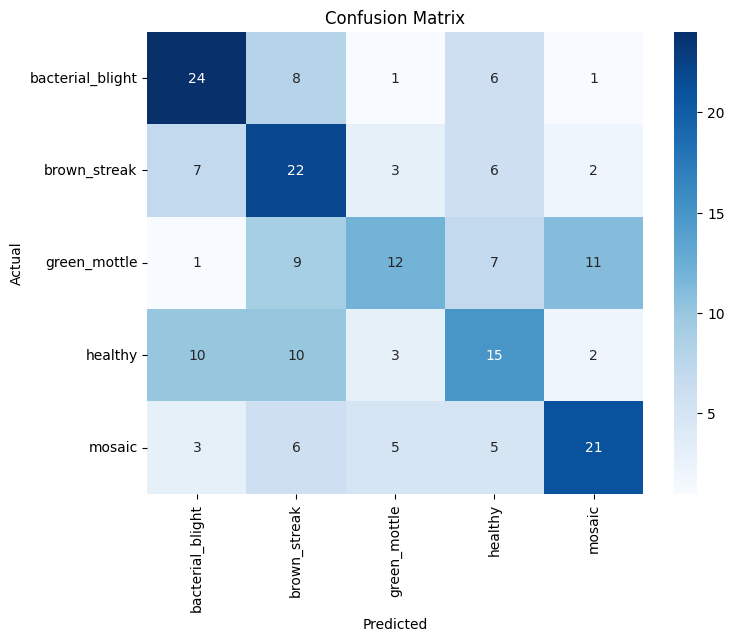

In [48]:
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [49]:
model.save("cassava_model.keras")
print("Model saved successfully")

Model saved successfully


In [56]:
test_image_path = "cassava_small/healthy/1046703257.jpg"

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 669ms/step


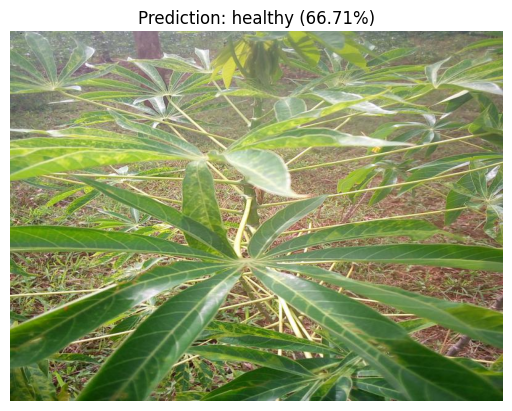

Predicted class: healthy
Confidence: 0.66714275


In [57]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

img = load_img(test_image_path, target_size=(224, 224))
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction)

plt.imshow(load_img(test_image_path))
plt.title(f"Prediction: {predicted_class} ({confidence:.2%})")
plt.axis("off")
plt.show()

print("Predicted class:", predicted_class)
print("Confidence:", confidence)